# 04 — Monte Carlo simulation: who wins the 2026 World Cup?

We replay the entire 48-team tournament **10,000 times**. Each match is a Poisson scoreline
driven by the teams' Elo; group standings use FIFA tie-breakers; the knockout bracket is the
**official** 2026 structure (Round of 32 -> Final). Reading off how often each team reaches
each stage gives honest probabilities.

Engine: [`src/simulation/`](../src/simulation/). Bracket rationale: `docs/decisions/ADR-004`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / "reports" / "figures"

from src.simulation.montecarlo import run_montecarlo  # noqa: E402

results = run_montecarlo(n=10_000, seed=42)
print(f"Simulated 10,000 tournaments. Title probabilities sum to {results['Champion'].sum():.2f}.")
results.head(10)

Simulated 10,000 tournaments. Title probabilities sum to 1.00.


,team,group,elo,Round of 32,Round of 16,Quarterfinal,Semifinal,Final,Champion
0,Spain,H,2230,0.9860,0.7314,0.5559,0.4304,0.2985,0.1953
1,Argentina,J,2194,0.9580,0.6486,0.5136,0.3528,0.2353,0.1442
2,France,I,2134,0.9219,0.6991,0.4565,0.2970,0.1640,0.0904
3,England,L,2099,0.9440,0.6377,0.3940,0.2322,0.1246,0.0619
4,Brazil,C,2073,0.9092,0.5618,0.3594,0.2006,0.1027,0.0512
5,Portugal,K,2065,0.8827,0.5729,0.3311,0.1822,0.0973,0.0477
6,Colombia,K,2068,0.8910,0.5770,0.3328,0.1802,0.0977,0.0464
7,Ecuador,E,2032,0.9148,0.5645,0.2844,0.1613,0.0769,0.0369
8,Netherlands,F,2014,0.8798,0.4664,0.2880,0.1467,0.0633,0.0289
9,Japan,F,1997,0.8599,0.4371,0.2620,0.1257,0.0573,0.0273


## 1. Title probabilities (the headline)

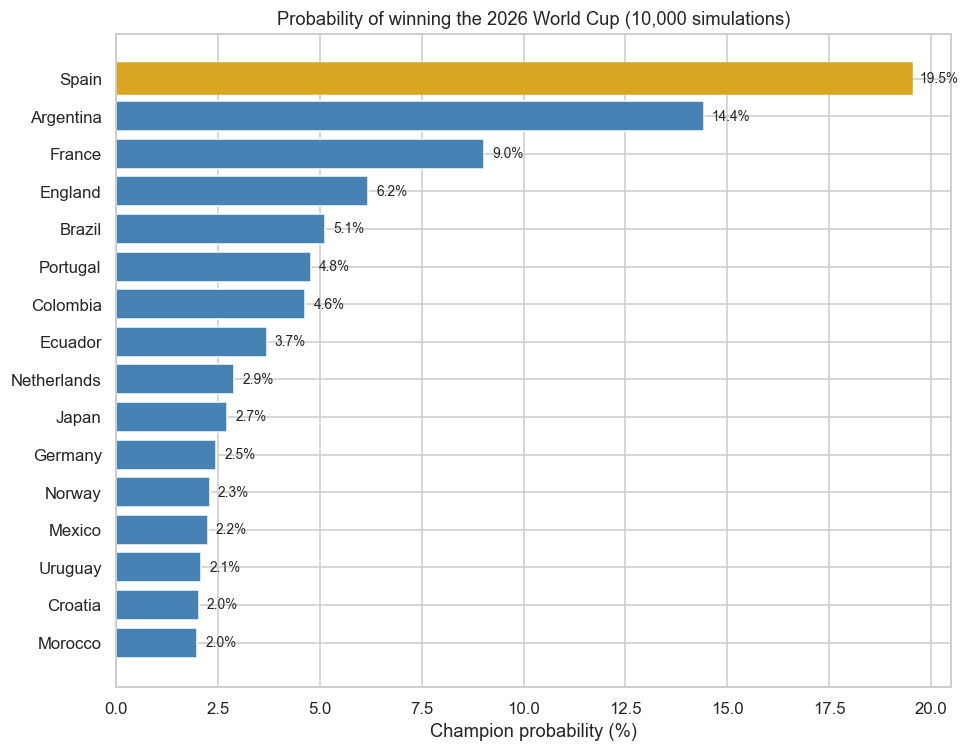

In [2]:
top = results.head(16)
fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top["team"][::-1], top["Champion"][::-1] * 100, color="steelblue")
bars[-1].set_color("goldenrod")  # highlight the favorite
ax.set(title="Probability of winning the 2026 World Cup (10,000 simulations)",
       xlabel="Champion probability (%)")
for i, v in enumerate(top["Champion"][::-1] * 100):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_title_probabilities.png", bbox_inches="tight")
plt.show()

## 2. The road to the final — stage-reach 'survival curves'

For the leading contenders, how the probability decays from reaching the Round of 32 down to
lifting the trophy. The gap between curves shows where a team is expected to bow out.

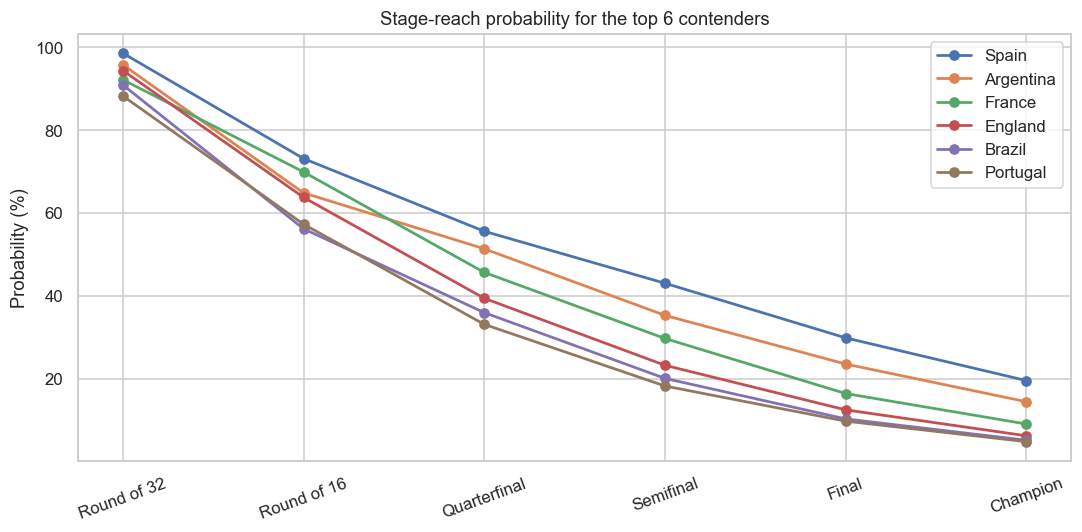

In [3]:
from src.simulation.bracket import STAGES  # noqa: E402

fig, ax = plt.subplots(figsize=(10, 5))
for _, row in results.head(6).iterrows():
    ax.plot(STAGES, [row[s] * 100 for s in STAGES], "o-", label=row["team"], lw=1.8)
ax.set(title="Stage-reach probability for the top 6 contenders", ylabel="Probability (%)")
ax.legend()
plt.xticks(rotation=20)
fig.tight_layout()
fig.savefig(FIG_DIR / "11_stage_progression.png", bbox_inches="tight")
plt.show()

## 3. Internal consistency check: Poisson goals vs the logistic classifier

We built two independent models: a **logistic classifier** (notebook 03) and a **Poisson
goals model** (used by the simulation). If both are sound, the W/D/L probabilities *implied*
by the Poisson scorelines should roughly match the classifier on the same out-of-time test
set. Agreement is reassuring evidence; large disagreement would signal a bug.

In [4]:
from src.models.goals import implied_outcome_probs  # noqa: E402
from src.models.train import load_features, temporal_split, build_model, evaluate, FEATURES  # noqa: E402
from src.simulation.engine import load_goals_params  # noqa: E402

df = load_features()
train_df, test_df = temporal_split(df)
y_te = test_df["target_idx"].to_numpy()

# Classifier probabilities on the test set.
clf = build_model().fit(train_df[FEATURES], train_df["target_idx"])
probs_clf = clf.predict_proba(test_df[FEATURES])

# Poisson-implied probabilities on the same matches.
params = load_goals_params()
is_home = (1 - test_df["is_neutral"]).to_numpy()
probs_poisson = np.array([
    implied_outcome_probs(params.lam(ed, ih), params.lam(-ed, 0))
    for ed, ih in zip(test_df["elo_diff"], is_home)
])

comp = pd.DataFrame([
    evaluate("Logistic classifier", y_te, probs_clf),
    evaluate("Poisson-implied", y_te, probs_poisson),
])
display(comp.style.format({"accuracy": "{:.3f}", "log_loss": "{:.4f}",
                           "brier": "{:.4f}", "rps": "{:.4f}"}).hide(axis="index"))
print("Close scores => the two independent models agree. Good internal consistency.")

C:\Dev\Worldcup\.venv\Lib\site-packages\sklearn\metrics\_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


model,accuracy,log_loss,brier,rps
Logistic classifier,0.599,0.8765,0.5151,0.1718
Poisson-implied,0.601,0.8768,0.5156,0.1720


Close scores => the two independent models agree. Good internal consistency.


## Conclusions & honest limitations

- The model produces **calibrated, well-spread** title odds — the favorite sits well under
  50%, correctly reflecting football's high variance. There is no false certainty.
- The two independent models (logistic & Poisson) **agree** on out-of-sample scores, which
  is good evidence the pipeline is internally consistent.

**Limitations (stated openly):**
- No squad/injury/player-level data — strength is purely team-level (Elo + form).
- Host nations are modeled on neutral ground (no home-crowd boost) — a documented refinement.
- Independent Poisson slightly under-models draws (Dixon-Coles is the v2 fix).
- Group third-place tie-breaks beyond GD/GF are resolved by lot (random), as in reality.

The point of this project is a **rigorous, explainable, reproducible** forecasting pipeline —
not a crystal ball. Every probability here can be traced back to data and documented choices.